# 02 — EDA (Exploratory Data Analysis)

Análisis exploratorio sobre el dataset ya limpio (`01_cleaning.ipynb`).

**Entrada:** `data/processed/wines_SPA_clean.csv`

**Cubre:** distribuciones de precio, rating, región, variedad de uva y crianza, más un par de comprobaciones adicionales (consistencia interna y riesgo de fuga de datos) pensadas de cara al motor de recomendación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/processed/wines_SPA_clean.csv')
print('Forma:', df.shape)
df.head(3)

Forma: (2024, 12)


,winery,wine_name,year,rating,region,price_euros,vine_type,grape_variety,wine_ageing,service_temperature,quality_price_ratio,luxury_category
0,Teso La Monja,Tinto,2013,4.9,Toro,995.00,Tinto,Tempranillo,0,16-18°C,0.005,1
1,Artadi,Vina El Pison,2018,4.9,Vino de Espana,313.50,Tinto,Tempranillo,0,16-18°C,0.016,1
2,Vega Sicilia,Unico,2009,4.8,Ribera del Duero,324.95,Tinto,Tempranillo,0,16-18°C,0.015,1


## 1. Vista general

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2024 entries, 0 to 2023
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   winery               2024 non-null   str    
 1   wine_name            2024 non-null   str    
 2   year                 2024 non-null   int64  
 3   rating               2024 non-null   float64
 4   region               2024 non-null   str    
 5   price_euros          2024 non-null   float64
 6   vine_type            2024 non-null   str    
 7   grape_variety        2024 non-null   str    
 8   wine_ageing          2024 non-null   int64  
 9   service_temperature  2024 non-null   str    
 10  quality_price_ratio  2024 non-null   float64
 11  luxury_category      2024 non-null   int64  
dtypes: float64(3), int64(3), str(6)
memory usage: 189.9 KB


In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
winery,2024,480,Vega Sicilia,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wine_name,2024,847,Tinto,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,2024.0,NaN,NaN,NaN,2011.254941,11.064822,1910.0,2010.0,2015.0,2017.0,2021.0
rating,2024.0,NaN,NaN,NaN,4.403508,0.146242,4.2,4.3,4.4,4.5,4.9
region,2024,76,Ribera del Duero,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_euros,2024.0,NaN,NaN,NaN,136.447932,273.553253,4.99,32.0,53.95,110.85,3119.08
vine_type,2024,5,Tinto,1694,NaN,NaN,NaN,NaN,NaN,NaN,NaN
grape_variety,2024,16,Tempranillo,1109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wine_ageing,2024.0,NaN,NaN,NaN,0.206028,0.404551,0.0,0.0,0.0,0.0,1.0
service_temperature,2024,5,16-18°C,1694,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Distribución de precio (`price_euros`)

El precio suele venir muy sesgado a la derecha (pocos vinos muy caros estiran la media). Se mira en escala normal y en log para comparar.

In [4]:
print(df['price_euros'].describe())
print(f"\nAsimetría (skew): {df['price_euros'].skew():.2f}")

count    2024.000000
mean      136.447932
std       273.553253
min         4.990000
25%        32.000000
50%        53.950000
75%       110.850000
max      3119.080000
Name: price_euros, dtype: float64

Asimetría (skew): 5.09


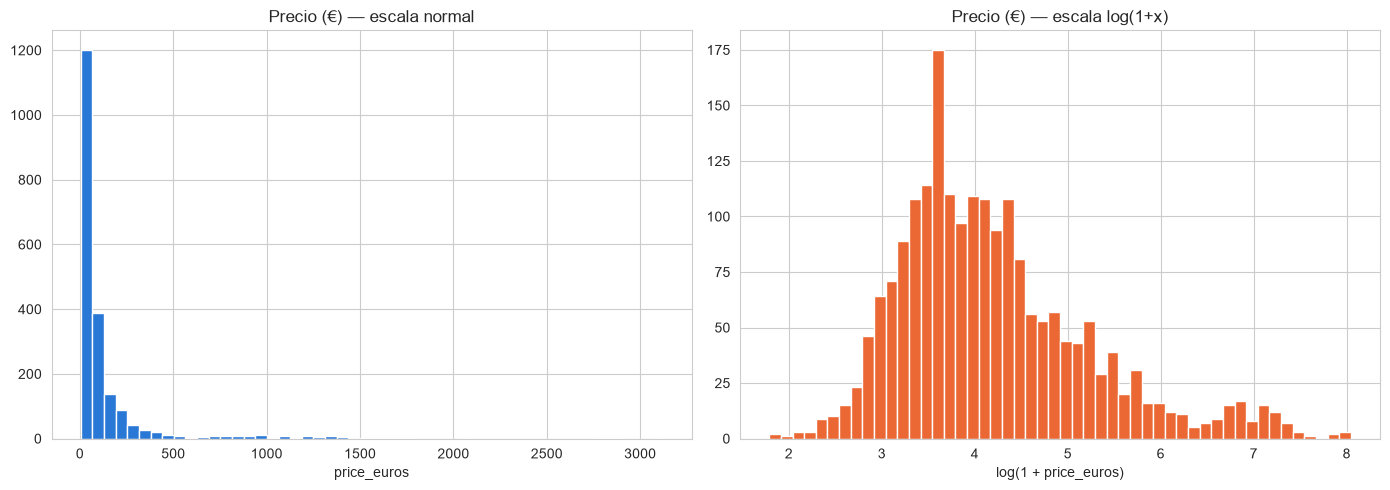

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price_euros'], bins=50, color='#2a78d6', edgecolor='white')
axes[0].set_title('Precio (€) — escala normal')
axes[0].set_xlabel('price_euros')

axes[1].hist(np.log1p(df['price_euros']), bins=50, color='#eb6834', edgecolor='white')
axes[1].set_title('Precio (€) — escala log(1+x)')
axes[1].set_xlabel('log(1 + price_euros)')

plt.tight_layout()
plt.show()

**Conclusión:** la distribución en escala normal está muy concentrada a la izquierda con una cola larga de vinos caros — confirma que cualquier modelo basado en distancia (KNN, clustering) debería usar `price_euros` en log o escalado, no en su escala original.

## 3. Distribución de rating

**Aviso importante:** este dataset viene de Kaggle ya filtrado a vinos bien valorados — el rating tiene muy poca varianza real.

In [6]:
print(df['rating'].describe())
print(f"\nValores únicos de rating: {sorted(df['rating'].unique())}")

count    2024.000000
mean        4.403508
std         0.146242
min         4.200000
25%         4.300000
50%         4.400000
75%         4.500000
max         4.900000
Name: rating, dtype: float64

Valores únicos de rating: [np.float64(4.2), np.float64(4.3), np.float64(4.4), np.float64(4.5), np.float64(4.6), np.float64(4.7), np.float64(4.8), np.float64(4.9)]


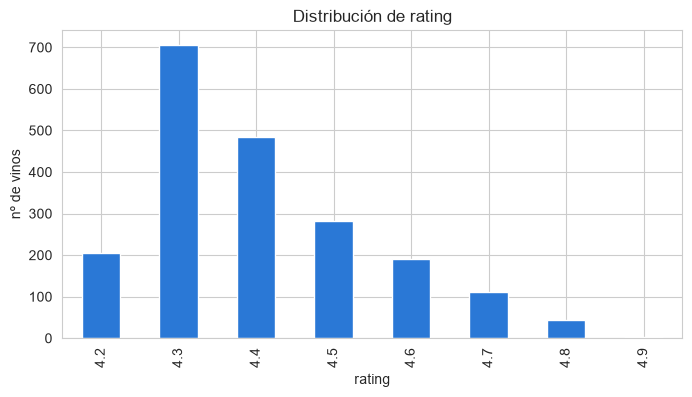

In [7]:
plt.figure(figsize=(8, 4))
df['rating'].value_counts().sort_index().plot(kind='bar', color='#2a78d6')
plt.title('Distribución de rating')
plt.xlabel('rating')
plt.ylabel('nº de vinos')
plt.show()

**Conclusión:** el rango real es 4.2–4.9 (percentiles 25/50/75 muy cercanos entre sí). Como feature para el recomendador aporta poca capacidad de diferenciación — no hay que fiarse de él como señal fuerte de "calidad", es un sesgo del dataset de origen, no un hallazgo real sobre los vinos.

## 4. Distribución por región

In [8]:
top_regions = df['region'].value_counts()
print(f"Nº de regiones distintas: {df['region'].nunique()}")
print(f"\nTop 15 regiones:")
print(top_regions.head(15))

Nº de regiones distintas: 76

Top 15 regiones:
region
Ribera del Duero      537
Rioja                 469
Priorato              248
Toro                   81
Castilla y Leon        51
Vino de Espana         44
Cava                   34
Rias Baixas            33
Jerez-Xeres-Sherry     28
Montilla-Moriles       26
Jumilla                26
Bierzo                 25
Emporda                25
Sardon de Duero        24
Penedes                22
Name: count, dtype: int64


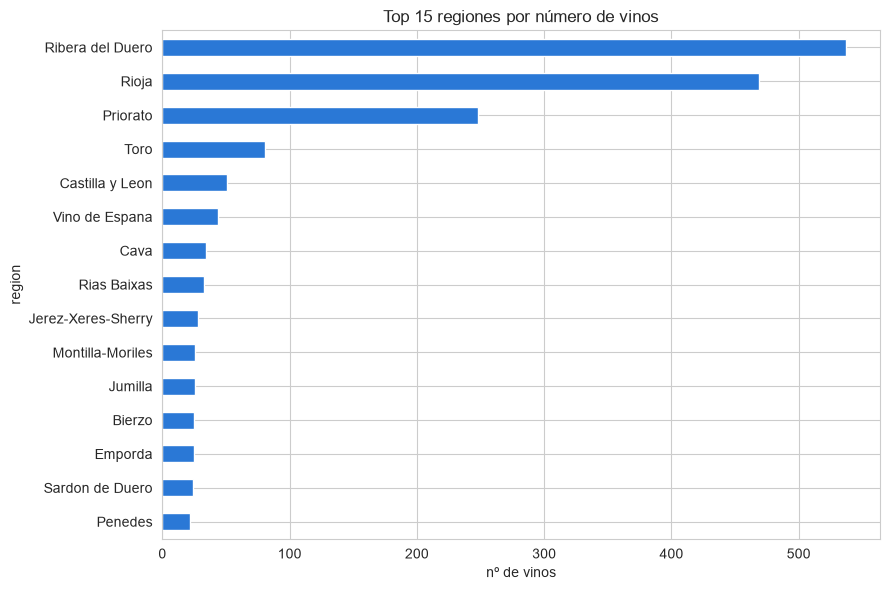

In [9]:
plt.figure(figsize=(9, 6))
top_regions.head(15).sort_values().plot(kind='barh', color='#2a78d6')
plt.title('Top 15 regiones por número de vinos')
plt.xlabel('nº de vinos')
plt.tight_layout()
plt.show()

**Conclusión:** hay 69 regiones pero muy desiguales — Ribera del Duero y Rioja concentran una parte grande del dataset, y hay una cola larga de regiones con muy pocos vinos. Esto es justo lo que justifica usar Target Encoding en vez de One-Hot para `region` en el preprocesamiento (69 columnas dummy, la mayoría casi vacías, no aportaría nada bueno).

## 5. Distribución por tipo y variedad de uva

In [10]:
print('=== vine_type ===')
print(df['vine_type'].value_counts())
print()
print('=== grape_variety (top 10) ===')
print(df['grape_variety'].value_counts().head(10))

=== vine_type ===
vine_type
Tinto          1694
Blanco          137
Generoso         90
Desconocido      65
Espumoso         38
Name: count, dtype: int64

=== grape_variety (top 10) ===
grape_variety
Tempranillo            1109
Blend/Other             400
Grenache / Carinena     248
Pedro Ximenez            35
Grenache                 35
Viura                    34
Albarino                 33
Monastrell               31
Verdejo                  27
Mencia                   16
Name: count, dtype: int64


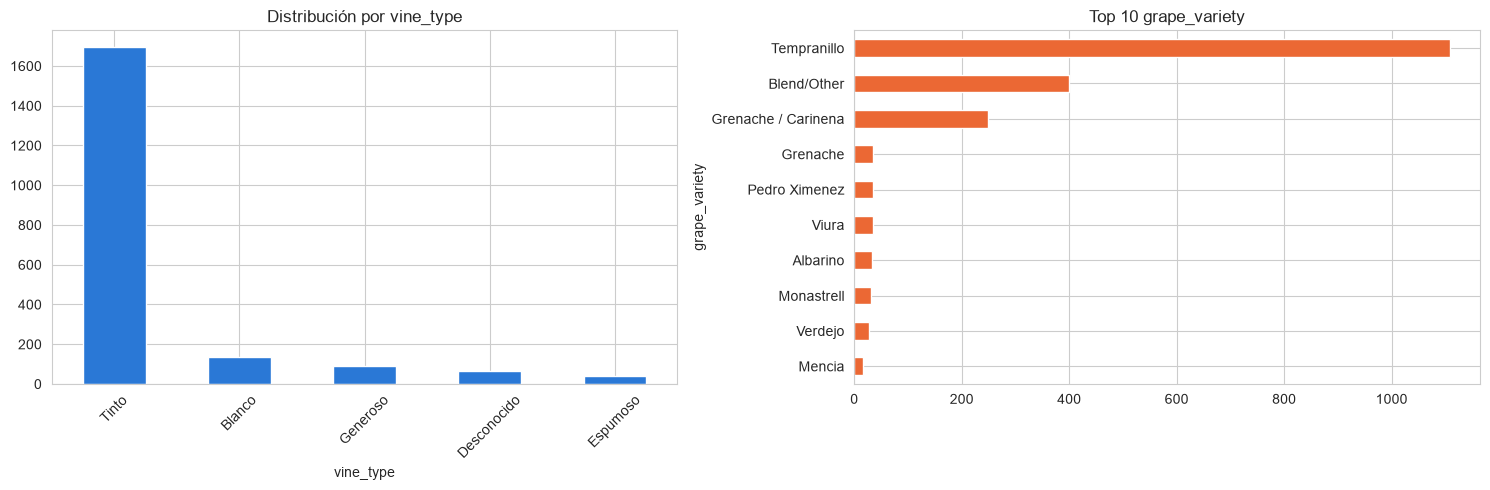

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df['vine_type'].value_counts().plot(kind='bar', ax=axes[0], color='#2a78d6')
axes[0].set_title('Distribución por vine_type')
axes[0].tick_params(axis='x', rotation=45)

df['grape_variety'].value_counts().head(10).sort_values().plot(
    kind='barh', ax=axes[1], color='#eb6834'
)
axes[1].set_title('Top 10 grape_variety')

plt.tight_layout()
plt.show()

**Conclusión:** Tempranillo domina ampliamente (esperable — es la uva insignia de Rioja y Ribera del Duero, las dos regiones con más vinos). `Blend/Other` sigue siendo la segunda categoría más común (~20%) — son regiones sin una uva dominante clara según los consejos reguladores (Mallorca, Costers del Segre...), así que se dejó así a propósito en vez de forzar una regla.

## 6. Crianza (`wine_ageing`)

In [12]:
print(df['wine_ageing'].value_counts())
print(f"\n% con crianza: {df['wine_ageing'].mean():.1%}")

wine_ageing
0    1607
1     417
Name: count, dtype: int64

% con crianza: 20.6%


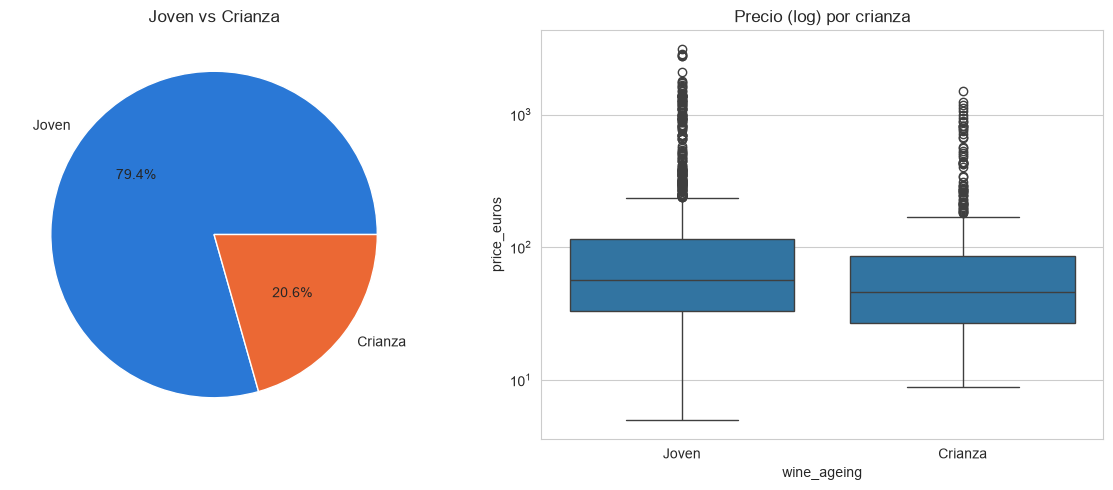

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['wine_ageing'].value_counts().plot(
    kind='pie', ax=axes[0], labels=['Joven', 'Crianza'], autopct='%1.1f%%',
    colors=['#2a78d6', '#eb6834']
)
axes[0].set_ylabel('')
axes[0].set_title('Joven vs Crianza')

sns.boxplot(data=df, x='wine_ageing', y='price_euros', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Joven', 'Crianza'])
axes[1].set_title('Precio (log) por crianza')

plt.tight_layout()
plt.show()

**Conclusión:** los vinos con crianza tienden a ser algo más caros de media, aunque hay mucho solape — recuerda que `wine_ageing` se deriva del *nombre* del vino (si menciona 'Crianza'/'Reserva'/'Barrica'), así que no es un dato 100% fiable para vinos que sí tienen crianza pero no lo indican en el nombre.

## 7. Correlaciones entre variables numéricas

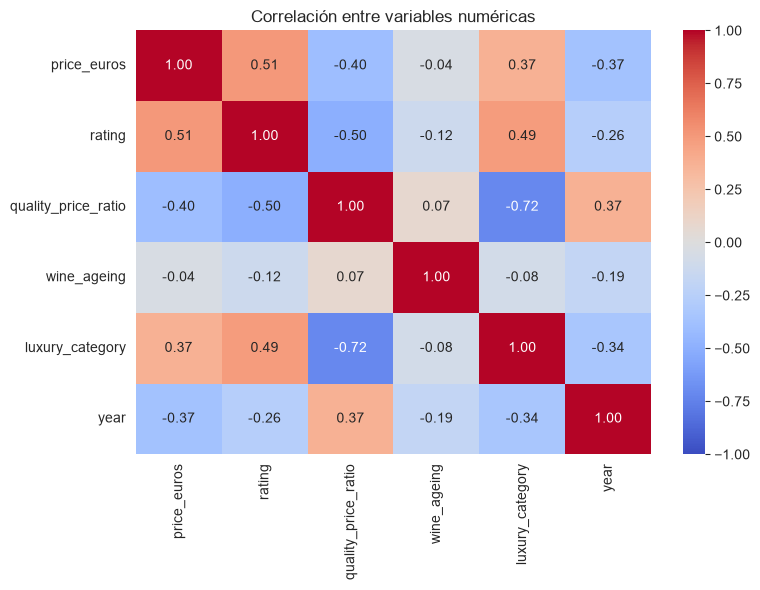

In [14]:
numeric_cols = ['price_euros', 'rating', 'quality_price_ratio', 'wine_ageing', 'luxury_category', 'year']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación entre variables numéricas')
plt.tight_layout()
plt.show()

**Conclusión:** `quality_price_ratio` correlaciona fuerte y negativamente con `luxury_category` y `price_euros` — es esperable, porque se calcula dividiendo por el precio. Ojo al meter las tres en un motor de similitud: estarían triple-contando la misma información de precio.

## 8. Consistencia interna: `vine_type` vs `grape_variety`

Comprobación de que ningún vino tinto tiene marcada una uva exclusivamente blanca, o viceversa (ya validado en `01_cleaning.ipynb`, se repite aquí como chequeo de sanidad del EDA).

In [15]:
RED_VARIETIES = {'Tempranillo','Monastrell','Grenache','Grenache / Carinena',
                 'Mencia','Bobal','Syrah','Cabernet Sauvignon'}
WHITE_VARIETIES = {'Albarino','Verdejo','Chardonnay','Godello','Treixadura',
                   'Palomino','Viura','Macabeo','Xarel-lo','Parellada','Sauvignon Blanc'}

inconsist = df[
    ((df['vine_type'] == 'Blanco') & (df['grape_variety'].isin(RED_VARIETIES)))
    | ((df['vine_type'] == 'Tinto') & (df['grape_variety'].isin(WHITE_VARIETIES)))
]
print(f'Filas inconsistentes: {len(inconsist)}')

Filas inconsistentes: 0


## 9. Riesgo de fuga de datos: mismo vino en varias añadas

Importante de cara al split train/test del motor de recomendación: muchos vinos aparecen varias veces con distinta añada. Si no se separa por vino (no solo por fila) al hacer el split, el mismo vino puede acabar en train y test a la vez, inflando artificialmente el rendimiento del modelo.

In [16]:
n_years_per_wine = df.groupby(['winery', 'wine_name'])['year'].nunique()

print(f"Vinos únicos (bodega + nombre): {len(n_years_per_wine)}")
print(f"Filas totales: {len(df)}")
print()
print('Distribución de nº de añadas distintas por vino:')
print(n_years_per_wine.describe())
print()
print(f"Vinos con más de 5 añadas distintas: {(n_years_per_wine > 5).sum()}")

Vinos únicos (bodega + nombre): 931
Filas totales: 2024

Distribución de nº de añadas distintas por vino:
count    931.000000
mean       2.172932
std        2.762879
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       41.000000
Name: year, dtype: float64

Vinos con más de 5 añadas distintas: 63


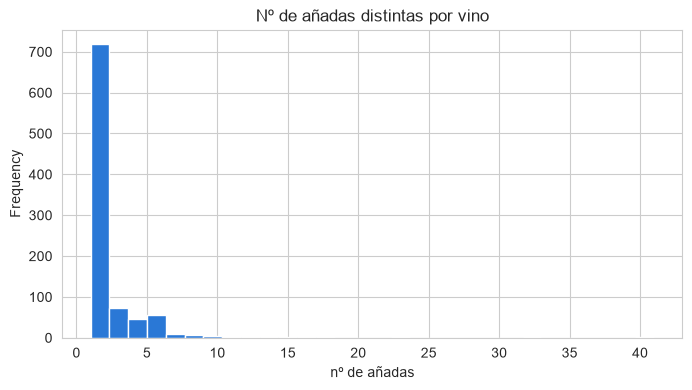

In [17]:
plt.figure(figsize=(8, 4))
n_years_per_wine.plot(kind='hist', bins=30, color='#2a78d6', edgecolor='white')
plt.title('Nº de añadas distintas por vino')
plt.xlabel('nº de añadas')
plt.show()

**Conclusión:** hay que hacer el split train/test agrupando por `(winery, wine_name)`, no fila a fila — por ejemplo con `GroupShuffleSplit` de scikit-learn usando ese par como grupo — para que ninguna añada del mismo vino se filtre entre train y test.

## 10. Resumen de hallazgos

| Hallazgo | Implicación para el modelo |
|---|---|
| Precio muy asimétrico | Escalar en log antes de calcular distancias |
| Rating casi sin varianza (4.2–4.9) | No usarlo como señal fuerte de calidad |
| Región muy desigual (69 categorías) | Target Encoding, no One-Hot |
| `Blend/Other` ~20% en grape_variety | Aceptado — no forzar regla donde no hay uva dominante clara |
| `quality_price_ratio` correlaciona con precio/lujo | No meter las tres variables juntas en el motor de similitud |
| Mismo vino en varias añadas | Split train/test agrupado por (winery, wine_name) |
| 0 inconsistencias vine_type/grape_variety | Dataset consistente, listo para preprocesamiento |